In [1]:
# =========================
# Import Libraries
# =========================
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Load Dataset
# =========================
df = pd.read_csv("df_transformer_ready.csv")

print(df.head())

                                                text  label_encoded
0  nevermind, every other weekend... i googled it...              1
1  [name] was arrested for lying and obstruction,...              1
2        well damn i’m going to the buckingham today              1
3  these are both beauties. those big dark eyes a...              0
4                                 ! remind me 2 days              1


In [2]:
# =========================
# Inputs and Labels
# =========================
X = df['text'].astype(str)
y = df['label_encoded']

In [3]:
# =========================
# Convert Labels to Categorical
# =========================
from tensorflow.keras.utils import to_categorical
y = to_categorical(y, num_classes=3)

In [4]:
# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# =========================
# Tokenization
# =========================
max_words = 5000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [6]:
# =========================
# Padding
# =========================
max_length = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

In [7]:
# =========================
# Build LSTM Model
# =========================
model = Sequential()

model.add(Embedding(input_dim=max_words,output_dim=64,input_length=max_length))

model.add(LSTM(64))

model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [8]:
# =========================
# Compile Model
# =========================
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [9]:
# =========================
# Early Stopping
# =========================
early_stop = EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)

In [10]:
# =========================
# Train Model
# =========================
history = model.fit(X_train_pad,y_train,epochs=5,batch_size=32,validation_split=0.2,callbacks=[early_stop])

Epoch 1/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - accuracy: 0.3830 - loss: 1.0844 - val_accuracy: 0.3641 - val_loss: 1.0839
Epoch 2/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.3715 - loss: 1.0767 - val_accuracy: 0.3611 - val_loss: 1.0762
Epoch 3/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.5464 - loss: 0.8776 - val_accuracy: 0.5980 - val_loss: 0.8135
Epoch 4/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.6279 - loss: 0.7350 - val_accuracy: 0.6251 - val_loss: 0.7944
Epoch 5/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - accuracy: 0.7319 - loss: 0.6149 - val_accuracy: 0.6917 - val_loss: 0.7644


In [11]:
# =========================
# Evaluate Model
# =========================
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6912 - loss: 0.7484
Test Accuracy: 0.6912485361099243


In [12]:
# =========================
# Predictions
# =========================
y_pred = model.predict(X_test_pad)

y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


In [13]:
# =========================
# Classification Report
# =========================
labels = ['Low', 'Medium', 'High']

print(classification_report(y_test_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.88      0.43      0.58      1357
           1       0.58      0.76      0.66      1353
           2       0.73      0.86      0.79      1575

    accuracy                           0.69      4285
   macro avg       0.73      0.68      0.67      4285
weighted avg       0.73      0.69      0.68      4285



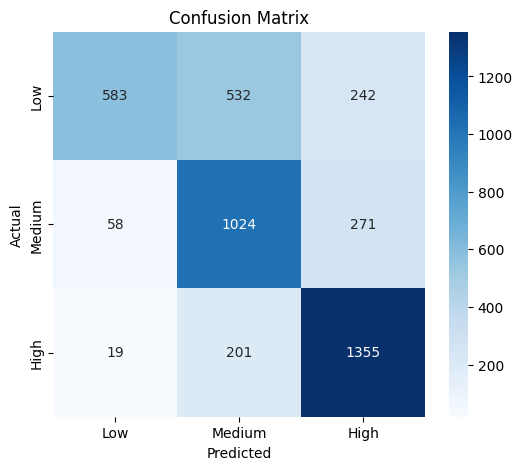

In [14]:
# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


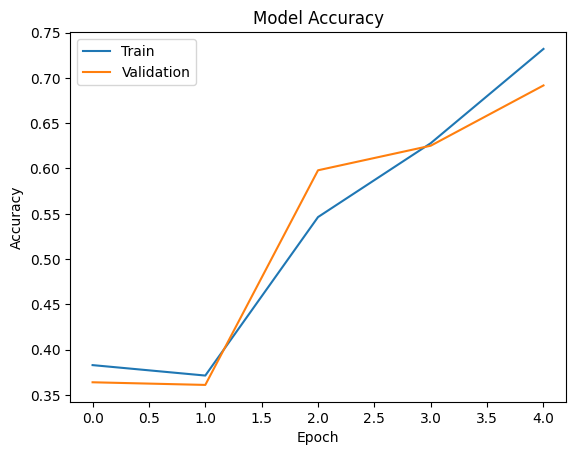

In [15]:
# =========================
# Accuracy Graph
# =========================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

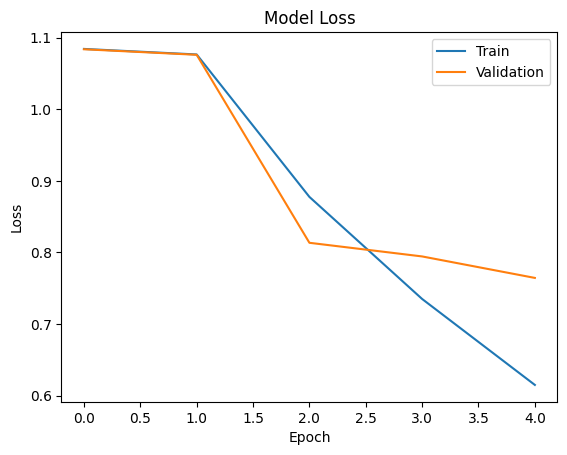

In [16]:
# =========================
# Loss Graph
# =========================
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [17]:
# =========================
# Sample Predictions
# =========================
print("\nSample Predictions:\n")

for i in range(5):
    print("Text:", X_test.iloc[i])
    print("Actual:", labels[y_test_classes[i]])
    print("Predicted:", labels[y_pred_classes[i]])
    print("------")


Sample Predictions:

Text: i loved that man so much and tried my best to make it work. but i have limits. and when he was not thinking twice about getting alcohol while we didn’t have even enough money left for milk for our baby, that was my limit. we had .51 cents in our account and he found that acceptable? !
Actual: High
Predicted: Medium
------
Text: i've been burned out for years. there are multiple people in my life with crippling depression or other severe mental health struggles, and i am pretty much they only person the can ever go to for help. of course, i want to help them. i want them to be happy. but it's been over 10 years of constantly hopping from one crisis to another and never getting a break. i can't even feel empathy any more. i can barely feel anything at all. i feel like i'm never allowed to be upset or to take a break because i have to be constantly strong for everyone else, and i'm just so tired that i want to leave everyone in y life and just disappear for a y

In [18]:
# =========================
# Save Results
# =========================
results_df = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test_classes,
    'predicted': y_pred_classes
})

results_df['actual_label'] = results_df['actual'].map({
    0: 'Low',
    1: 'Medium',
    2: 'High'
})

results_df['predicted_label'] = results_df['predicted'].map({
    0: 'Low',
    1: 'Medium',
    2: 'High'
})

results_df.to_csv("lstm_predictions.csv", index=False)

print("Results saved to lstm_predictions.csv")

Results saved to lstm_predictions.csv
